In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

CUDA Available: True
Device: cuda


In [6]:
import os

print("Level 2:", os.listdir("/kaggle/input/datasets/vishnudharsh"))

Level 2: ['cliniscan-preprocessed-5000', 'cliniscan-labels-5000']


In [7]:
import os

print("Preprocessed folder:")
print(os.listdir("/kaggle/input/datasets/vishnudharsh/cliniscan-preprocessed-5000"))

print("\nLabels folder:")
print(os.listdir("/kaggle/input/datasets/vishnudharsh/cliniscan-labels-5000"))

Preprocessed folder:
['kaggle']

Labels folder:
['labels_5000.csv']


In [9]:
import os

print(os.listdir("/kaggle/input/datasets/vishnudharsh/cliniscan-preprocessed-5000/kaggle/working"))
print(len(os.listdir("/kaggle/input/datasets/vishnudharsh/cliniscan-preprocessed-5000/kaggle/working/preprocessed_jpg_5000")))

['preprocessed_jpg_5000']
5000


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score

In [8]:
print("CUDA Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CUDA Available: True
Device: cuda


In [9]:
IMG_DIR = "/kaggle/input/datasets/vishnudharsh/cliniscan-preprocessed-5000/kaggle/working/preprocessed_jpg_5000"
LABELS_CSV = "/kaggle/input/datasets/vishnudharsh/cliniscan-labels-5000/labels_5000.csv"

df = pd.read_csv(LABELS_CSV)

print("Total samples:", len(df))
df.head()

Total samples: 5000


,image_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Consolidation,ILD,Infiltration,Lung Opacity,No finding,Nodule/Mass,Other lesion,Pleural effusion,Pleural thickening,Pneumothorax,Pulmonary fibrosis
0,50a418190bc3fb1ef1633bf9678929b3.jpg,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,21a10246a5ec7af151081d0cd6d65dc9.jpg,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,051132a778e61a86eb147c7c6f564dfe.jpg,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,063319de25ce7edb9b1c6b8881290140.jpg,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,1c32170b4af4ce1a3030eb8167753b06.jpg,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [10]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

Train: 3500
Validation: 750
Test: 750


In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [15]:
class ChestXrayDataset(Dataset):
    
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx,0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            self.data.iloc[idx,1:].values.astype(np.float32)
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
train_dataset = ChestXrayDataset("train.csv", IMG_DIR, train_transform)
val_dataset = ChestXrayDataset("val.csv", IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 219
Validation batches: 47


In [17]:
model = models.efficientnet_b0(weights="DEFAULT")

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 15)

model = model.to(device)

print("EfficientNet-B0 loaded successfully")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


EfficientNet-B0 loaded successfully


In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
num_epochs = 20
best_f1 = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    all_labels = []
    all_outputs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            all_labels.append(labels.cpu())
            all_outputs.append(torch.sigmoid(outputs).cpu())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    all_labels = torch.cat(all_labels).numpy()
    all_outputs = torch.cat(all_outputs).numpy()

    f1 = f1_score(all_labels, all_outputs>0.5, average="macro")
    auc = roc_auc_score(all_labels, all_outputs, average="macro")

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(),"best_model_sample.hcl")

100%|██████████| 219/219 [01:02<00:00,  3.50it/s]



Epoch [1/20]
Train Loss: 0.2123
Val Loss: 0.1692
F1 Score: 0.2078
AUC: 0.8816


100%|██████████| 219/219 [00:27<00:00,  8.00it/s]



Epoch [2/20]
Train Loss: 0.1693
Val Loss: 0.1467
F1 Score: 0.2646
AUC: 0.9158


100%|██████████| 219/219 [00:27<00:00,  8.05it/s]


...


Epoch [18/20]
Train Loss: 0.1012
Val Loss: 0.1475
F1 Score: 0.3871
AUC: 0.9315


100%|██████████| 219/219 [00:27<00:00,  7.94it/s]



Epoch [19/20]
Train Loss: 0.0975
Val Loss: 0.1499
F1 Score: 0.3658
AUC: 0.9276


100%|██████████| 219/219 [00:27<00:00,  7.84it/s]



Epoch [20/20]
Train Loss: 0.0919
Val Loss: 0.1497
F1 Score: 0.3641
AUC: 0.9319


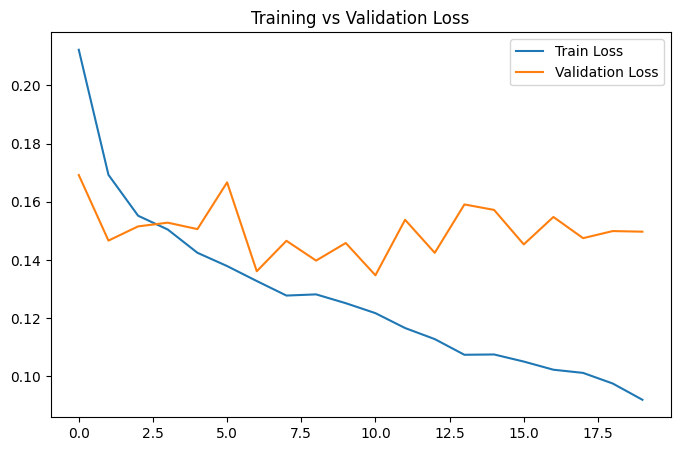

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.legend()
plt.title("Training vs Validation Loss")

plt.show()